# Quantum Travel Mode Classification using Qiskit

This notebook demonstrates a binary classification task in the travel domain using a quantum kernel method with Qiskit.

In [1]:
!pip install -U "qiskit==0.43.1" "qiskit-machine-learning==0.6.1"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.5/241.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.1 MB/s eta 0:00:00
  Created wheel for qiskit: file

In [1]:
import numpy as np
np.random.seed(42)

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

from qiskit.circuit.library import ZFeatureMap
from qiskit_machine_learning.kernels import QuantumKernel


In [2]:
def generate_travel_data(n_samples=100):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=3,
        n_informative=3,
        n_redundant=0,
        n_classes=2,      # 0: Train, 1: Flight
        random_state=42
    )
    return X, y

X, y = generate_travel_data()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [5]:
from qiskit import Aer

In [6]:
feature_map = ZFeatureMap(feature_dimension=3, reps=2)
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=Aer.get_backend('aer_simulator'))


In [7]:
kernel_matrix_train = quantum_kernel.evaluate(x_vec=X_train)
kernel_matrix_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)


In [8]:
qsvm = SVC(kernel="precomputed")
qsvm.fit(kernel_matrix_train, y_train)

y_pred = qsvm.predict(kernel_matrix_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.83      0.56        12
           1       0.67      0.22      0.33        18

    accuracy                           0.47        30
   macro avg       0.54      0.53      0.44        30
weighted avg       0.57      0.47      0.42        30



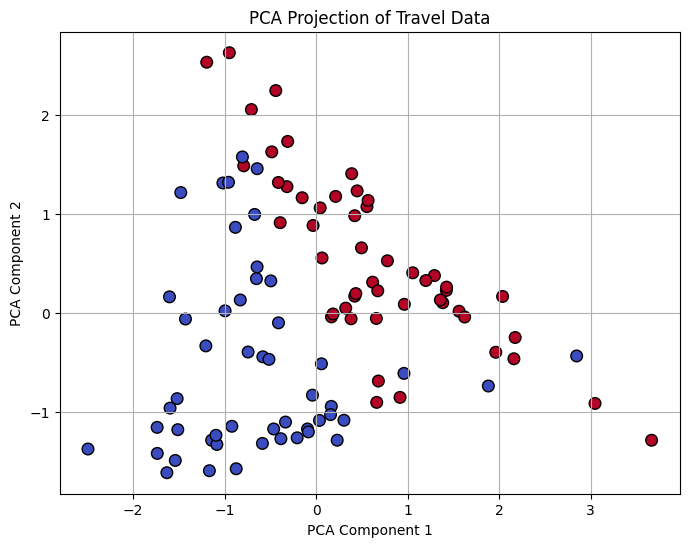

In [9]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=70)
plt.title("PCA Projection of Travel Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()
